# Импорт библиотек

In [464]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, BisectingKMeans, HDBSCAN
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline

# EDA

In [391]:
df = pd.read_excel('data/result2022.xlsx')

In [392]:
df.head()

,"Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ","Средний балл ЕГЭ студентов университета, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы Российской Федерации, за исключением лиц, поступивших с учетом особых прав и в рамках квоты целевого приема","Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета с оплатой стоимости затрат на обучение физическими и юридическими лицами","Усредненный по реализуемым направлениям (специальностям) минимальный балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме на программы бакалавриата и специалитета","Численность студентов, победителей и призеров заключительного этапа всероссийской олимпиады школьников, членов сборных команд Российской Федерации, участвовавших в международных олимпиадах по общеобразовательным предметам по специальностям и (или) направлениям подготовки, соответствующим профилю всероссийской олимпиады школьников или международной олимпиады, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета без вступительных испытаний","Численность студентов, победителей и призеров олимпиад школьников, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета по специальностям и (или) направлениям подготовки, соответствующим профилю олимпиады школьников, без вступительных испытаний","Численность студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета","Удельный вес численности студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета в общей численности студентов, принятых на первый курс по программам бакалавриата и специалитета на очную форму обучения","Удельный вес численности студентов (приведенного контингента), обучающихся по программам магистратуры, в общей численности приведенного контингента обучающихся по образовательным программам бакалавриата, специалитета и магистратуры","Удельный вес численности обучающихся (приведенного контингента), по программам магистратуры, подготовки научно-педагогических кадров в аспирантуре (адъюнктуре), ординатуры, ассистентуры-стажировки в общей численности приведенного контингента обучающихся по основным образовательным программам высшего образования",...,Доля доходов вуза от образовательной деятельности в общих доходах вуза,Доля доходов вуза от научных исследований и разработок в общих доходах вуза,Доля внебюджетных средств в доходах от образовательной деятельности,Доля внебюджетных средств в доходах от научных исследований и разработок,VUZ,Region,Type,Site,ID,year
0,0.00,0.00,61.28,48.28,0,0,0,0.0,8.34,8.34,...,80.76,4.42,100.00,100.00,Автономная некоммерческая образовательная орга...,Воронежская область,Частные образовательные организации,http://www.vepi.ru,110170,2022
1,51.69,51.69,51.48,39.26,0,0,0,0.0,0.00,0.00,...,66.01,11.19,34.13,100.00,Автономная некоммерческая образовательная орга...,Воронежская область,Частные образовательные организации,http://www.iict.ru,1996,2022
2,0.00,0.00,0.00,0.00,0,0,0,0.0,0.00,0.00,...,97.58,0.00,100.00,0.00,Автономная некоммерческая образовательная орга...,Курская область,Частные образовательные организации,http://rfei.ru/,2071,2022
3,0.00,0.00,55.70,55.70,0,0,0,0.0,0.00,0.00,...,68.66,1.53,100.00,100.00,Автономная некоммерческая образовательная орга...,Московская область,Частные образовательные организации,https://www.pssi-k.ru/,666667486,2022
4,0.00,0.00,0.00,0.00,0,0,0,0.0,100.00,100.00,...,9.09,85.08,9.77,12.17,Автономная некоммерческая образовательная орга...,г.Москва,Частные образовательные организации,www.skoltech.ru,113493,2022


Посмотрим размер датасета

In [393]:
df.shape

(681, 133)

Быстрый обзор типов/пропусков

In [394]:
df.dtypes.head(30)

Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ                                                                                                                                                                                                                                                                                                        float64
Средний балл ЕГЭ студентов университета, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы Российской Федерации, за исключением лиц, поступивших с учетом особых прав и в рамках квоты целевого приема                                                                                                                                                                                  float64
Средний балл ЕГЭ сту

Нужна нормализация названия столбцов, произведем ее

In [395]:
col_rename = {
    "Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ": "ege_avg_budget_full_time",
    "Средний балл ЕГЭ студентов университета, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы Российской Федерации, за исключением лиц, поступивших с учетом особых прав и в рамках квоты целевого приема": "ege_avg_budget_full_time_no_special_rights_no_target_quota",
    "Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета с оплатой стоимости затрат на обучение физическими и юридическими лицами": "ege_avg_paid_full_time",
    "Усредненный по реализуемым направлениям (специальностям) минимальный балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме на программы бакалавриата и специалитета": "ege_min_avg_full_time",
    "Численность студентов, победителей и призеров заключительного этапа всероссийской олимпиады школьников, членов сборных команд Российской Федерации, участвовавших в международных олимпиадах по общеобразовательным предметам по специальностям и (или) направлениям подготовки, соответствующим профилю всероссийской олимпиады школьников или международной олимпиады, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета без вступительных испытаний": "olympiad_final_winners_admitted_no_exams",
    "Численность студентов, победителей и призеров олимпиад школьников, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета по специальностям и (или) направлениям подготовки, соответствующим профилю олимпиады школьников, без вступительных испытаний": "school_olympiad_winners_admitted_no_exams",
    "Численность студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета": "target_admission_count_full_time",
    "Удельный вес численности студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета в общей численности студентов, принятых на первый курс по программам бакалавриата и специалитета на очную форму обучения": "target_admission_share_full_time",
    "Удельный вес численности студентов (приведенного контингента), обучающихся по программам магистратуры, в общей численности приведенного контингента обучающихся по образовательным программам бакалавриата, специалитета и магистратуры": "masters_share_in_total_contingent",
    "Удельный вес численности обучающихся (приведенного контингента), по программам магистратуры, подготовки научно-педагогических кадров в аспирантуре (адъюнктуре), ординатуры, ассистентуры-стажировки в общей численности приведенного контингента обучающихся по основным образовательным программам высшего образования": "postgrad_and_residency_share_in_total_contingent",
    "Удельный вес численности студентов, имеющих диплом бакалавра, специалиста или магистра других организаций, принятых на первый курс на обучение по программам магистратуры образовательной организации, в общей численности студентов, принятых на первый курс по программам магистратуры на очную форму обучения": "masters_admitted_from_other_orgs_share_full_time",
    "Удельный вес численности обучающихся по программам магистратуры, подготовки научно-педагогических кадров в аспирантуре (адъюнктуре), ординатуры, ассистентуры-стажировки, имеющих диплом бакалавра, диплом специалиста или диплом магистра других организаций в общей численности обучающихся по программам магистратуры, подготовки научно-педагогических кадров в аспирантуре (адъюнктуре), ординатуры, ассистентуры-стажировки": "postgrad_from_other_orgs_share",
    "Численность аспирантов (адъюнктов), ординаторов, ассистентов-стажеров образовательной организации в расчете на 100 студентов (приведенного контингента)": "postgrad_per_100_students",
    "Удельный вес численности слушателей из сторонних организаций в общей численности слушателей, прошедших обучение в образовательной организации по программам повышения квалификации или профессиональной переподготовки": "dpo_external_listeners_share",
    "Удельный вес численности студентов, обучающихся по направлениям подготовки бакалавриата, специалитета, и магистратуры по областям знаний «Инженерное дело, технологии и технические науки», «Здравоохранение и медицинские науки», «Образование и педагогические науки», с которыми заключены договоры о целевом обучении, в общей численности студентов, обучающихся по указанным областям знаний": "target_contract_share_priority_fields",

    "Количество цитирований публикаций, изданных за последние 5 лет, индексируемых в информационно-аналитической системе научного цитирования Web of Science Core Collection в расчете на 100 НПР[н]": "citations_wos_5y_per_100_faculty",
    "Количество цитирований публикаций, изданных за последние 5 лет, индексируемых в информационно-аналитической системе научного цитирования Scopus в расчете на 100 НПР[н]": "citations_scopus_5y_per_100_faculty",
    "Количество цитирований публикаций, изданных за последние 5 лет, индексируемых в Российском индексе научного цитирования (далее – РИНЦ) в расчете на 100 НПР[н]": "citations_rinc_5y_per_100_faculty",
    "Число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования Web of Science Core Collection, в расчете на 100 НПР[н]": "publications_wos_per_100_faculty",
    "Число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования Scopus, в расчете на 100 НПР[н]": "publications_scopus_per_100_faculty",
    "Число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования РИНЦ, в расчете на 100 НПР[н]": "publications_rinc_per_100_faculty",
    "Общий объем научно-исследовательских и опытно-конструкторских работ (далее – НИОКР)": "rnd_total_volume",
    "Удельный вес доходов от НИОКР в общих доходах образовательной организации": "rnd_income_share_total",
    "Удельный вес НИОКР, выполненных собственными силами (без привлечения соисполнителей), в общих доходах образовательной организации от НИОКР": "rnd_own_work_share_in_rnd_income",
    "Доходы от НИОКР (за исключением средств бюджетов бюджетной системы Российской Федерации, государственных фондов поддержки науки) в расчете на одного НПР[н]": "rnd_income_per_faculty_excl_budget",
    "Количество лицензионных соглашений": "license_agreements_count",
    "Удельный вес средств, полученных образовательной организацией от использования результатов интеллектуальной деятельности, в общих доходах образовательной организации": "rid_income_share_total",
    "Удельный вес численности НПР без ученой степени – до 30 лет, кандидатов наук – до 35 лет, докторов наук – до 40 лет, в общей численности НПР[н]": "young_faculty_share",
    "Удельный вес научно-педагогических работников, защитивших кандидатские и докторские диссертации за отчетный период в общей численности НПР": "defended_theses_share",
    "Количество научных журналов, в том числе электронных, издаваемых образовательной организацией": "journals_count",
    "Количество полученных грантов за отчетный год в расчете на 100 НПР[н]": "grants_per_100_faculty",

    "Удельный вес численности иностранных студентов (кроме стран Содружества Независимых Государств (далее – СНГ)), обучающихся программам бакалавриата, специалитета, магистратуры, в общей численности студентов (приведенный контингент)": "foreign_students_non_cis_share",
    "Удельный вес численности иностранных студентов из СНГ, обучающихся по программам бакалавриата, специалитета, магистратуры, в общей численности студентов (приведенный контингент)": "foreign_students_cis_share",
    "Удельный вес численности иностранных студентов, завершивших освоение образовательных программ бакалавриата, специалитета, магистратуры, в общей численности студентов (приведенный контингент)": "foreign_graduates_share",
    "Удельный вес численности иностранных студентов (кроме стран СНГ), завершивших освоение образовательных программ бакалавриата, программ специалитета, программ магистратуры, в общей численности студентов (приведенный контингент)": "foreign_graduates_non_cis_share",
    "Удельный вес численности иностранных студентов из стран СНГ, завершивших освоение образовательных программ бакалавриата, программ специалитета, программ магистратуры, в общей численности студентов (приведенный контингент)": "foreign_graduates_cis_share",
    "Удельный вес численности студентов, обучающихся по очной форме обучения по образовательным программам бакалавриата, программам специалитета, программам магистратуры, прошедших обучение за рубежом не менее семестра (триместра), в общей численности студентов, обучающихся по очной форме обучения": "outbound_mobility_semester_share",
    "Численность студентов иностранных образовательных организаций, прошедших обучение в образовательной организации по образовательным по очной форме обучения по образовательным программам бакалавриата, программам специалитета, программам магистратуры, не менее семестра (триместра) в расчете на 100 студентов, обучающихся по очной форме обучения": "inbound_mobility_per_100_students",
    "Удельный вес численности иностранных граждан из числа НПР в общей численности НПР": "foreign_faculty_share",
    "Численность зарубежных ведущих профессоров, преподавателей и исследователей, работающих (работавших) в образовательной организации не менее 1 семестра": "visiting_professors_count",
    "Удельный вес численности иностранных граждан (кроме стран СНГ) из числа аспирантов (адъюнктов), ординаторов, ассистентов-стажеров образовательной организации в общей численности аспирантов (адъюнктов), ординаторов, ассистентов-стажеров": "foreign_postgrad_non_cis_share",
    "Удельный вес численности иностранных граждан из стран СНГ из числа аспирантов (адъюнктов), ординаторов, ассистентов-стажеров образовательной организации в общей численности аспирантов (адъюнктов), ординаторов, ассистентов-стажеров": "foreign_postgrad_cis_share",
    "Объем средств, полученных образовательной организацией от выполнения НИОКР от иностранных граждан и иностранных юридических лиц": "rnd_funds_from_foreign_entities",
    "Объем средств от образовательной деятельности, полученных образовательной организацией от иностранных граждан и иностранных юридических лиц": "edu_funds_from_foreign_entities",

    "Доходы образовательной организации из средств от приносящей доход деятельности в расчете на одного НПР": "income_nonbudget_per_faculty",
    "Доля доходов из средств от приносящей доход деятельности в доходах по всем видам финансового обеспечения (деятельности) образовательной организации": "income_nonbudget_share_total",
    "Отношение средней заработной платы НПР в образовательной организации (из всех источников) к средней заработной плате по экономике региона": "faculty_salary_to_region_avg_ratio",
    "Доходы образовательной организации из всех источников в расчете на численность студентов (приведенный контингент)": "income_per_student",
    "Общая площадь учебно-лабораторных помещений в расчете на одного студента (приведенного контингента),в том числе:": "teaching_lab_area_per_student_total",
    "имеющихся на праве собственности": "teaching_lab_area_owned",
    "закрепленных на праве оперативного управления": "teaching_lab_area_operational",
    "предоставленных в безвозмездное пользование": "teaching_lab_area_free_use",
    "предоставленных в аренду": "teaching_lab_area_rented",
    "Количество персональных компьютеров в расчете на одного студента (приведенного контингента)": "pcs_per_student",
    "Удельный вес стоимости машин и оборудования (не старше 5 лет) в общей стоимости машин и оборудования": "equipment_under_5y_value_share",
    "Количество экземпляров печатных учебных изданий (включая учебники и учебные пособия) из общего количества единиц хранения библиотечного фонда, состоящих на учете, в расчете на одного студента (приведенного контингента)": "printed_textbooks_per_student",
    "Удельный вес НПР, имеющих ученую степень кандидата наук, в общей численности НПР": "faculty_phd_share",
    "Удельный вес НПР имеющих ученую степень доктора наук, в общей численности НПР": "faculty_dsc_share",
    "Удельный вес НПР, имеющих ученую степень кандидата и доктора наук, в общей численности НПР образовательной организации (без совместителей и работающих по договорам гражданско-правового характера)": "faculty_phd_dsc_share",
    "Число НПР, имеющих ученую степень кандидата и доктора наук, в расчете на 100 студентов": "faculty_phd_dsc_per_100_students",
    "Доля штатных работников ППС в общей численности ППС": "faculty_staff_share",

    "2": "section_2",
    "Образовательная деятельность": "section_education",
    "Общая численность студентов, обучающихся по программам бакалавриата, специалитета, магистратуры": "students_total",
    "в том числе:по очной форме обучения": "students_full_time",
    "по очно-заочной (вечерней) форме обучения": "students_part_time_evening",
    "по заочной форме обучения": "students_correspondence",
    "Средний балл ЕГЭ студентов, принятых на обучение по программам бакалавриата и специалитета, по всем формам обучения": "ege_avg_all_forms",
    "Доля обучающихся по программам бакалавриата, специалитета, магистратуры в очной форме": "share_full_time",
    "Доля обучающихся по программам бакалавриата в общей численности обучающихся по программам бакалавриата, специалитета, магистратуры": "share_bachelor_in_total",
    "Доля обучающихся по программам магистратуры в общей численности обучающихся по программам бакалавриата, специалитета, магистратуры": "share_master_in_total",
    "Общая численность слушателей программ дополнительного профессионального образования": "dpo_listeners_total",
    "Общая численность обучающихся по программам среднего профессионального образования": "spo_students_total",
    "Число предприятий, с которыми заключены договоры на подготовку специалистов": "partner_enterprises_count",
    "Число предприятий, являющихся базами практики, с которыми оформлены договорные отношения": "practice_bases_count",

    "Научная деятельность": "section_research",
    "Общий объем средств, поступивших (за отчетный год) от выполнения НИОКР, выполненных собственными силами": "rnd_funds_own_total",
    "Общий объем средств, поступивших (за отчетный год) от выполнения работ, услуг, связанных с научными, научно-техническими, творческими услугами и разработками, выполненных собственными силами": "research_services_funds_own_total",
    "Общее количество публикаций организации в расчете на 100 НПР": "publications_total_per_100_faculty",
    "Количество бизнес-инкубаторов": "incubators_count",
    "Количество технопарков": "technoparks_count",
    "Количество центров коллективного пользования научным оборудованием": "shared_equipment_centers_count",
    "Количество малых предприятий": "small_enterprises_count",
    "Общая численность аспирантов (адъюнктов), интернов, ординаторов, ассистентов-стажеров": "postgrads_total",
    "Доля аспирантов (адъюнктов), интернов, ординаторов, ассистентов-стажеров, обучающихся в очной форме": "postgrads_full_time_share",
    "Общая численность докторантов": "doctoral_students_total",
    "Число диссертационных советов": "dissertation_councils_count",

    "Кадровый потенциал": "section_hr",
    "Общая численность работников образовательной организации (без внешних совместителей и работающих по договорам ГПХ)": "employees_total",
    "Общая численность ППС (без внешних совместителей и работающих по договорам ГПХ)": "faculty_total",
    "Общая численность научных работников (без внешних совместителей и работающих по договорам ГПХ)": "researchers_total",
    "Доля ППС, имеющих ученые степени": "faculty_degree_share",
    "Доля научных работников, имеющих ученые степени": "researchers_degree_share",
    "Доля ППС возрастной категории моложе 65 лет": "faculty_under_65_share",
    "Доля ППС возрастной категории моложе 40 лет": "faculty_under_40_share",
    "Средняя заработная плата ППС (без внешних совместителей и работающих по договорам ГПХ)": "faculty_avg_salary",
    "Средняя заработная плата научных работников (без внешних совместителей и работающих по договорам ГПХ)": "researchers_avg_salary",

    "Международная деятельность": "section_international",
    "Общая численность иностранных студентов, обучающихся по программам бакалавриата, специалитета, магистратуры": "foreign_students_total",
    "Доля иностранных студентов в общей численности студентов, обучающихся по программам бакалавриата, специалитета, магистратуры": "foreign_students_share_total",
    "Общее число образовательных программ высшего образования, реализуемых совместно с зарубежными вузами и ведущих к получению двух дипломов": "double_degree_programs_count",
    "Общая численность обучающихся по очной форме обучения по программам бакалавриата, специалитета, магистратуры, реализуемым совместно с зарубежными вузами и ведущим к получению двух дипломов": "double_degree_students_full_time_total",
    "Общая численность иностранных аспирантов (адъюнктов), интернов, ординаторов, ассистентов-стажеров": "foreign_postgrads_total",
    "Число статей, подготовленных совместно с зарубежными организациями": "intl_coauthored_articles_count",
    "Доходы вуза из иностранных источников на выполнение НИОКР": "rnd_income_foreign_sources",
    "Доходы вуза от образовательной деятельности из иностранных источников": "edu_income_foreign_sources",
    "Количество созданных результатов интеллектуальной деятельности, имеющих правовую охрану за пределами России": "rid_protected_abroad_count",

    "Инфраструктура": "section_infrastructure",
    "Общая площадь зданий (помещений)": "buildings_area_total",
    "Площадь учебно-лабораторных зданий": "teaching_lab_buildings_area",
    "Площадь, предназначенная для научно-исследовательских подразделений": "research_units_area",
    "Площадь общежитий": "dorms_area",
    "Площадь крытых спортивных сооружений": "indoor_sports_area",
    "Доля студентов, не обеспеченных собственным общежитием, в числе студентов, нуждающихся в общежитии": "dorm_shortage_share",
    "Количество персональных компьютеров": "pcs_total",
    "Доля персональных компьютеров, имеющих доступ к Интернету": "pcs_internet_share",
    "Наличие электронной библиотечной системы": "has_e_library_system",

    "Финансово-экономическая деятельность": "section_finance",
    "Доходы вуза из всех источников": "income_total",
    "Доходы вуза из внебюджетных источников": "income_nonbudget",
    "Доля доходов вуза из внебюджетных источников": "income_nonbudget_share",
    "Доля доходов вуза из федерального бюджета": "income_federal_budget_share",
    "Доля доходов вуза из бюджета субъекта РФ и местного бюджета": "income_regional_local_budget_share",
    "Доля доходов вуза от образовательной деятельности в общих доходах вуза": "income_edu_share_total",
    "Доля доходов вуза от научных исследований и разработок в общих доходах вуза": "income_research_share_total",
    "Доля внебюджетных средств в доходах от образовательной деятельности": "nonbudget_share_in_edu_income",
    "Доля внебюджетных средств в доходах от научных исследований и разработок": "nonbudget_share_in_research_income",

    "VUZ": "vuz",
    "Region": "region",
    "Type": "type",
    "Site": "site",
    "ID": "id",
    "year": "year",
}

In [396]:
df = df.rename(columns=col_rename)

In [397]:
df.head()

,ege_avg_budget_full_time,ege_avg_budget_full_time_no_special_rights_no_target_quota,ege_avg_paid_full_time,ege_min_avg_full_time,olympiad_final_winners_admitted_no_exams,school_olympiad_winners_admitted_no_exams,target_admission_count_full_time,target_admission_share_full_time,masters_share_in_total_contingent,postgrad_and_residency_share_in_total_contingent,...,income_edu_share_total,income_research_share_total,nonbudget_share_in_edu_income,nonbudget_share_in_research_income,vuz,region,type,site,id,year
0,0.00,0.00,61.28,48.28,0,0,0,0.0,8.34,8.34,...,80.76,4.42,100.00,100.00,Автономная некоммерческая образовательная орга...,Воронежская область,Частные образовательные организации,http://www.vepi.ru,110170,2022
1,51.69,51.69,51.48,39.26,0,0,0,0.0,0.00,0.00,...,66.01,11.19,34.13,100.00,Автономная некоммерческая образовательная орга...,Воронежская область,Частные образовательные организации,http://www.iict.ru,1996,2022
2,0.00,0.00,0.00,0.00,0,0,0,0.0,0.00,0.00,...,97.58,0.00,100.00,0.00,Автономная некоммерческая образовательная орга...,Курская область,Частные образовательные организации,http://rfei.ru/,2071,2022
3,0.00,0.00,55.70,55.70,0,0,0,0.0,0.00,0.00,...,68.66,1.53,100.00,100.00,Автономная некоммерческая образовательная орга...,Московская область,Частные образовательные организации,https://www.pssi-k.ru/,666667486,2022
4,0.00,0.00,0.00,0.00,0,0,0,0.0,100.00,100.00,...,9.09,85.08,9.77,12.17,Автономная некоммерческая образовательная орга...,г.Москва,Частные образовательные организации,www.skoltech.ru,113493,2022


In [398]:
df = df.drop('id', axis=1)

In [399]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 681 entries, 0 to 680
Columns: 132 entries, ege_avg_budget_full_time to year
dtypes: float64(90), int64(38), object(4)
memory usage: 702.4+ KB


Посмотрим на 4 колонки с типом object

In [400]:
df.select_dtypes(include='object')

,vuz,region,type,site
0,Автономная некоммерческая образовательная орга...,Воронежская область,Частные образовательные организации,http://www.vepi.ru
1,Автономная некоммерческая образовательная орга...,Воронежская область,Частные образовательные организации,http://www.iict.ru
2,Автономная некоммерческая образовательная орга...,Курская область,Частные образовательные организации,http://rfei.ru/
3,Автономная некоммерческая образовательная орга...,Московская область,Частные образовательные организации,https://www.pssi-k.ru/
4,Автономная некоммерческая образовательная орга...,г.Москва,Частные образовательные организации,www.skoltech.ru
...,...,...,...,...
676,федеральное государственное бюджетное образова...,Приморский край,Министерство здравоохранения Российской Федерации,https://tgmu.ru/
677,Федеральное государственное бюджетное образова...,Хабаровский край,Министерство науки и высшего образования Росси...,http://pnu.edu.ru
678,федеральное государственное бюджетное образова...,Хабаровский край,Министерство культуры Российской Федерации,http://www.hgiik.ru
679,Частное образовательное учреждение высшего обр...,Республика Бурятия,Частные образовательные организации,bepi-edu.ru


## Дубликаты

In [401]:
dup_rows = df.duplicated().sum()
dup_rows

0

## Пропуски

In [402]:
miss = (
    df.isna().mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
      .to_frame("missing_%")
)
miss.head(30)

,missing_%
publications_wos_per_100_faculty,100.0
citations_wos_5y_per_100_faculty,100.0
section_infrastructure,100.0
section_hr,100.0
has_e_library_system,100.0
publications_scopus_per_100_faculty,100.0
section_finance,100.0
citations_scopus_5y_per_100_faculty,100.0
section_international,100.0
section_research,100.0


Присутствуют пропуски и они 100% можно просто убрать эти столбцы

In [403]:
df = df.drop(['publications_scopus_per_100_faculty', 'section_infrastructure', 'section_finance', 'publications_wos_per_100_faculty', 'section_hr', 'citations_scopus_5y_per_100_faculty', 'citations_wos_5y_per_100_faculty', 'has_e_library_system', 'section_education', 'section_research', 'section_international'], axis=1)

## Константные / почти константные колонки

In [404]:
nunique = df.nunique(dropna=False).sort_values()
const_cols = nunique[nunique <= 1]
print("Константные колонки:", len(const_cols))
if len(const_cols):
    for col in const_cols.index:
        print(f"\nКолонка: {col}")
        print(f"Уникальные значения: {df[col].unique()}")
        print(f"Количество NaN: {df[col].isna().sum()}")

Константные колонки: 2

Колонка: year
Уникальные значения: [2022]
Количество NaN: 0

Колонка: section_2
Уникальные значения: [4]
Количество NaN: 0


In [405]:
near_const = []
for c in df.columns:
    vc = df[c].value_counts(dropna=False)
    if len(vc) == 0:
        continue
    if (vc.iloc[0] / len(df)) >= 0.99:
        near_const.append((c, float(vc.iloc[0] / len(df))))
near_const = sorted(near_const, key=lambda x: x[1], reverse=True)
print("Почти константные признаки:", len(near_const))
pd.DataFrame(near_const, columns=["col", "top_share"]).head(30)

Почти константные признаки: 2


,col,top_share
0,section_2,1.0
1,year,1.0


Удалим данные константные колонки

In [406]:
df = df.drop(['section_2', 'year'], axis=1)

In [407]:
df.shape

(681, 119)

## Описательная статистика

### Числовые

In [408]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

In [409]:
desc = df[num_cols].describe(percentiles=[.01, .05, .5, .95, .99]).T
desc.sort_values("std", ascending=False).head(30)

,count,mean,std,min,1%,5%,50%,95%,99%,max
income_total,681.0,1.544827e+06,3.053261e+06,62.00,4515.200,15500.00,689929.50,6024791.20,1.373365e+07,38320205.20
income_nonbudget,681.0,6.509417e+05,1.426923e+06,0.00,2751.520,10302.50,211070.10,2608756.30,6.858942e+06,15899410.50
research_services_funds_own_total,681.0,1.713239e+05,5.405918e+05,0.00,0.000,0.00,26708.80,858078.40,2.341808e+06,7566786.00
rnd_total_volume,681.0,1.710789e+05,5.395120e+05,0.00,0.000,0.00,27722.60,810576.00,2.374154e+06,7752989.00
rnd_funds_own_total,681.0,1.595528e+05,5.135417e+05,0.00,0.000,0.00,25058.20,783076.00,2.222736e+06,7566786.00
buildings_area_total,681.0,8.422733e+04,1.249793e+05,0.00,512.200,1666.00,52823.00,252815.00,5.751948e+05,1662182.00
edu_funds_from_foreign_entities,681.0,3.362995e+04,1.100230e+05,0.00,0.000,0.00,1794.30,167843.90,5.577539e+05,1717091.10
edu_income_foreign_sources,681.0,3.362995e+04,1.100230e+05,0.00,0.000,0.00,1794.30,167843.90,5.577539e+05,1717091.10
teaching_lab_buildings_area,681.0,5.439200e+04,7.486633e+04,0.00,512.200,1554.00,35036.00,166366.00,3.156436e+05,987056.00
dorms_area,681.0,2.137683e+04,3.274089e+04,0.00,0.000,0.00,12925.00,71675.00,1.403678e+05,359113.00


Выводы:
- Почти все финансовые и инфраструктурные показатели имеют среднее значительно выше медианы, очень большие 95–99 перцентили, огромной разрыв между min и max
- printed_textbooks_per_student – максимум в 300 раз больше медианы
- citations_rinc_5y_per_100_faculty – очень сильная асимметрия, но это возможная ситуация
- income_total vs income_nonbudget – в среднем внебюджет ≈ 42% от total, но распределение неравномерное
- R&D показатели – более 50% вузов не имеют иностранных R&D доходов (медиана = 0)
- студенты – есть крупные университеты, но значительная часть — средние и малые.
- иностранные студенты – часть вузов вообще не работает с иностранцами
- инфрастуктура – площадь вузов отличается более чем в 30 раз от медианы, 50% вузов имеют общежития
- income_per_student, rnd_income_per_faculty_excl_budget, income_nonbudget_per_faculty – показатели имеют сильную асимметрию

Посмотрим на выбросы

In [410]:
def iqr_stats(s):
    s = s.dropna()
    if len(s) < 5:
        return np.nan
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((s < lower) | (s > upper)).mean()
    return outliers

In [411]:
iqr_results = []

for c in num_cols:
    share = iqr_stats(df[c])
    iqr_results.append((c, share))

iqr_df = pd.DataFrame(iqr_results, columns=["column", "outlier_share"])
iqr_df.sort_values("outlier_share", ascending=False).head(30)

,column,outlier_share
1,ege_avg_budget_full_time_no_special_rights_no_...,0.243759
91,double_degree_programs_count,0.237885
0,ege_avg_budget_full_time,0.236417
42,faculty_salary_to_region_avg_ratio,0.233480
48,teaching_lab_area_rented,0.220264
92,double_degree_students_full_time_total,0.215859
72,incubators_count,0.211454
95,rnd_income_foreign_sources,0.209985
38,rnd_funds_from_foreign_entities,0.209985
5,school_olympiad_winners_admitted_no_exams,0.186490


Вывод:
- Довольно большие доли выбросов, но это скорее всего реальные данные и их нужно немного преобразовать

Посмотрим на ассиметрии

In [412]:
df[num_cols].skew().sort_values(ascending=False).head(20)

teaching_lab_area_free_use                  22.735288
defended_theses_share                       22.609292
researchers_total                           20.712987
faculty_phd_dsc_per_100_students            20.321835
double_degree_students_full_time_total      19.739178
printed_textbooks_per_student               18.203626
outbound_mobility_semester_share            18.126194
teaching_lab_area_owned                     18.089714
teaching_lab_area_rented                    15.573312
pcs_per_student                             15.338134
foreign_postgrads_total                     15.189386
olympiad_final_winners_admitted_no_exams    14.930794
rid_income_share_total                      14.383573
rid_protected_abroad_count                  13.921888
income_per_student                          13.216800
faculty_avg_salary                          12.868272
license_agreements_count                    12.029647
teaching_lab_area_per_student_total         11.835253
dissertation_councils_count 

Вывод:
- skewness > 11 — это экстремальная правосторонняя асимметрия
- логарифмирование почти обязательно или использование моделей, устойчивых к skew

Посмотрим корреляции

In [413]:
corr = df[num_cols].corr()

In [414]:
pairs = []
cols = corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = corr.iloc[i, j]
        if pd.notna(val):
            pairs.append((cols[i], cols[j], val, abs(val)))

corr_pairs = pd.DataFrame(pairs, columns=["col1", "col2", "corr", "abs_corr"])
corr_pairs.sort_values("abs_corr", ascending=False).head(50)

,col1,col2,corr,abs_corr
1992,rnd_income_share_total,income_research_share_total,1.000000,1.000000
3685,rnd_funds_from_foreign_entities,rnd_income_foreign_sources,1.000000,1.000000
3761,edu_funds_from_foreign_entities,edu_income_foreign_sources,1.000000,1.000000
3920,income_nonbudget_share_total,income_nonbudget_share,1.000000,1.000000
1853,rnd_total_volume,rnd_funds_own_total,0.997108,0.997108
5520,rnd_funds_own_total,research_services_funds_own_total,0.993054,0.993054
1854,rnd_total_volume,research_services_funds_own_total,0.990445,0.990445
5960,employees_total,faculty_total,0.963077,0.963077
0,ege_avg_budget_full_time,ege_avg_budget_full_time_no_special_rights_no_...,0.962754,0.962754
6419,buildings_area_total,teaching_lab_buildings_area,0.960476,0.960476


Вывод:
- абсолютная линейная зависимость у rnd_income_share_total — income_research_share_total,rnd_funds_from_foreign_entities — rnd_income_foreign_sources, edu_funds_from_foreign_entities — edu_income_foreign_sources, income_nonbudget_share_total — income_nonbudget_share. Надо будет убрать один из признаков пар.
- почти идеальная корреляция – rnd_total_volume — rnd_funds_own_total, rnd_funds_own_total — research_services_funds_own_total, rnd_total_volume — research_services_funds_own_total. Оставим один агрегированный показатель.
- корреляции масштаба вуза (employees_total, faculty_total, students_total, students_full_time, pcs_total, buildings_area_total, income_total, buildings_area_total, teaching_lab_buildings_area, dorms_area, pcs_total). Можно либо один агрегатный показатель (через PCA) либо нормализовать всё на размер (per student / per faculty).
- доли и shares (faculty_phd_dsc_share — faculty_degree_share, masters_share_in_total_contingent — share_master_in_total, income_nonbudget_share_total — nonbudget_share_in_edu_income). Оставить один признак из пары.
- пересечение плотности (teaching_lab_area_per_student_total — pcs_per_student). Оставим оба, так как это два содержательных признака.

### Категориальные

In [415]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

In [416]:
cat_summary = []

for col in cat_cols:
    cat_summary.append({
        "column": col,
        "unique_values": df[col].nunique(dropna=True),
        "missing_%": df[col].isna().mean() * 100,
        "top_value": df[col].mode(dropna=True)[0] if df[col].nunique(dropna=True) > 0 else None,
        "top_share_%": df[col].value_counts(normalize=True, dropna=True).iloc[0] * 100 if df[col].nunique(dropna=True) > 0 else None
    })
cat_summary_df = pd.DataFrame(cat_summary).sort_values("unique_values", ascending=False)
cat_summary_df

,column,unique_values,missing_%,top_value,top_share_%
0,vuz,681,0.0,Автономная некоммерческая образовательная орга...,0.146843
3,site,681,0.0,bepi-edu.ru,0.146843
1,region,97,0.0,г.Москва,19.089574
2,type,21,0.0,Министерство науки и высшего образования Росси...,31.424376


Вывод:
- нужно удалить vuz и site
- type (one-hot)
- region – убрать из кластеризации либо агрегировать до 8–10 групп

In [417]:
df = df.drop(columns=["site"])

In [418]:
df.shape

(681, 118)

# Предобработка данных

## Числовые

Удалим сильные мультиколлинеарности

In [419]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

In [420]:
high_corr = [column for column in upper.columns if any(upper[column] > 0.95)]

In [421]:
df = df.drop(columns=high_corr)

In [422]:
df.shape

(681, 105)

Удалим scale-признаков

In [423]:
scale_cols = [
    'students_total',
    'students_full_time',
    'employees_total',
    'faculty_total',
    'pcs_total',
    'buildings_area_total',
    'income_total',
    'rnd_total_volume'
]

In [424]:
scale_cols = [c for c in scale_cols if c in df.columns]

In [425]:
X_size = df[scale_cols].copy()

In [426]:
for c in X_size.columns:
    if X_size[c].min() >= 0:
        X_size[c] = np.log1p(X_size[c])

In [427]:
scaler = StandardScaler()
X_size_scaled = scaler.fit_transform(X_size)

In [428]:
pca = PCA(n_components=1)
size_factor = pca.fit_transform(X_size_scaled)

In [429]:
df["size_factor"] = size_factor
print("Объяснённая дисперсия:", pca.explained_variance_ratio_[0])

Объяснённая дисперсия: 0.8689313437524572


In [430]:
df = df.drop(columns=scale_cols)

In [431]:
df.shape

(681, 99)

Лог-преобразование

In [432]:
num_cols = df.select_dtypes(include=[np.number]).columns

In [433]:
skewness = df[num_cols].skew()

In [434]:
log_candidates = skewness[skewness > 2].index.tolist()

In [435]:
for col in log_candidates:
    if df[col].min() >= 0:
        df[col] = np.log1p(df[col])

Проверим выбросы после лог-преобразования

In [436]:
skewness = df[num_cols].skew()
log_candidates = skewness[skewness > 2].index.tolist()

In [437]:
transformed_cols = []

for col in log_candidates:
    if df[col].min() >= 0:
        df[col] = np.log1p(df[col])
        transformed_cols.append(col)

In [438]:
def iqr_outlier_share(series):
    s = series.dropna()
    if len(s) < 10:
        return np.nan

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return ((s < lower) | (s > upper)).mean()

In [439]:
results = []

for col in transformed_cols:
    share = iqr_outlier_share(df[col])
    results.append((col, share))

In [440]:
outliers_after_log = pd.DataFrame(results, columns=["column", "outlier_share_after_log"])
outliers_after_log = outliers_after_log.sort_values("outlier_share_after_log", ascending=False)
outliers_after_log.head(20)

,column,outlier_share_after_log
13,double_degree_programs_count,0.237885
10,teaching_lab_area_rented,0.218796
14,double_degree_students_full_time_total,0.215859
1,school_olympiad_winners_admitted_no_exams,0.186490
4,outbound_mobility_semester_share,0.182085
12,doctoral_students_total,0.182085
5,inbound_mobility_per_100_students,0.165932
16,income_regional_local_budget_share,0.133627
3,rid_income_share_total,0.127753
0,olympiad_final_winners_admitted_no_exams,0.108664


Большая часть heavy-tail признаков стала более компактной

## Категориальные

Обработка region

In [441]:
macro_region_map = {
    # Central
    'г.Москва': 'Central', 'Московская область': 'Central',
    'Белгородская область': 'Central', 'Брянская область': 'Central',
    'Владимирская область': 'Central', 'Воронежская область': 'Central',
    'Ивановская область': 'Central', 'Калужская область': 'Central',
    'Костромская область': 'Central', 'Курская область': 'Central',
    'Липецкая область': 'Central', 'Орловская область': 'Central',
    'Рязанская область': 'Central', 'Смоленская область': 'Central',
    'Тамбовская область': 'Central', 'Тверская область': 'Central',
    'Тульская область': 'Central', 'Ярославская область': 'Central',

    # Northwest
    'г.Санкт-Петербург': 'Northwest', 'Ленинградская область': 'Northwest',
    'Архангельская область': 'Northwest', 'Вологодская область': 'Northwest',
    'Калининградская область': 'Northwest', 'Мурманская область': 'Northwest',
    'Новгородская область': 'Northwest', 'Псковская область': 'Northwest',
    'Республика Карелия': 'Northwest', 'Республика Коми': 'Northwest',

    # Volga
    'Республика Татарстан': 'Volga', 'Республика Башкортостан': 'Volga',
    'Самарская область': 'Volga', 'Нижегородская область': 'Volga',
    'Пермский край': 'Volga', 'Саратовская область': 'Volga',
    'Ульяновская область': 'Volga', 'Пензенская область': 'Volga',
    'Оренбургская область': 'Volga', 'Республика Мордовия': 'Volga',
    'Чувашская Республика': 'Volga', 'Кировская область': 'Volga',
    'Республика Марий Эл': 'Volga',

    # South
    'Краснодарский край': 'South', 'Ростовская область': 'South',
    'Волгоградская область': 'South', 'Астраханская область': 'South',
    'Республика Адыгея': 'South', 'Республика Калмыкия': 'South',

    # North Caucasus
    'Республика Дагестан': 'NorthCaucasus', 'Ставропольский край': 'NorthCaucasus',
    'Республика Ингушетия': 'NorthCaucasus',
    'Республика Северная Осетия-Алания': 'NorthCaucasus',
    'Кабардино-Балкарская Республика': 'NorthCaucasus',
    'Карачаево-Черкесская Республика': 'NorthCaucasus',
    'Чеченская Республика': 'NorthCaucasus',

    # Ural
    'Свердловская область': 'Ural', 'Челябинская область': 'Ural',
    'Тюменская область': 'Ural', 'Курганская область': 'Ural',
    'Ханты-Мансийский автономный округ': 'Ural',
    'Ямало-Ненецкий автономный округ': 'Ural',

    # Siberia
    'Новосибирская область': 'Siberia', 'Красноярский край': 'Siberia',
    'Иркутская область': 'Siberia', 'Кемеровская область': 'Siberia',
    'Томская область': 'Siberia', 'Омская область': 'Siberia',
    'Алтайский край': 'Siberia', 'Республика Алтай': 'Siberia',
    'Республика Тыва': 'Siberia', 'Республика Хакасия': 'Siberia',

    # Far East
    'Приморский край': 'FarEast', 'Хабаровский край': 'FarEast',
    'Амурская область': 'FarEast', 'Сахалинская область': 'FarEast',
    'Камчатский край': 'FarEast', 'Магаданская область': 'FarEast',
    'Республика Саха (Якутия)': 'FarEast',
    'Еврейская автономная область': 'FarEast',
    'Чукотский автономный округ': 'FarEast'
}

In [442]:
df['macro_reg'] = df['region'].map(macro_region_map)
df['macro_reg'] = df['macro_reg'].fillna('other')

In [443]:
macro_counts = df['macro_reg'].value_counts()
macro_counts

macro_reg
Central          239
Volga            101
Northwest         78
Siberia           68
South             47
Ural              45
NorthCaucasus     39
other             33
FarEast           31
Name: count, dtype: int64

In [444]:
df[df.macro_reg == "other"]

,ege_avg_budget_full_time,ege_avg_paid_full_time,ege_min_avg_full_time,olympiad_final_winners_admitted_no_exams,school_olympiad_winners_admitted_no_exams,target_admission_count_full_time,target_admission_share_full_time,masters_share_in_total_contingent,postgrad_and_residency_share_in_total_contingent,masters_admitted_from_other_orgs_share_full_time,...,pcs_internet_share,income_federal_budget_share,income_regional_local_budget_share,income_edu_share_total,nonbudget_share_in_research_income,vuz,region,type,size_factor,macro_reg
7,0.00,77.03,37.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,...,100.00,0.00,0.000000,94.02,100.00,"Автономная некоммерческая организация ""Образов...",г.Москва\t,Частные образовательные организации,-2.831622,other
64,80.30,66.48,46.30,0.000000,0.000000,0.693147,0.350657,3.663562,3.670715,100.00,...,100.00,7.82,0.354360,93.01,21.79,Негосударственное образовательное частное учре...,г.МоскваЮридический адрес:,Частные образовательные организации,-0.022884,other
85,0.00,62.74,47.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,...,100.00,0.00,0.300591,82.08,100.00,Религиозная духовная образовательная организац...,"Тульская областьул. Руднева, 43 А, пос. Заокск...",Частные образовательные организации,-3.951648,other
89,59.60,74.00,44.00,0.000000,0.000000,0.000000,0.000000,3.278653,3.528711,17.65,...,100.00,10.49,0.000000,94.22,0.00,Религиозная организация - духовная образовател...,Московская областьРоссия,Частные образовательные организации,-1.828616,other
92,0.00,0.00,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,...,100.00,0.00,0.000000,100.00,0.00,Религиозная организация Образовательная органи...,"г.Москваг. Москва, улица Фабрициуса дом 31ана ...",Частные образовательные организации,-6.972600,other
301,63.32,60.77,43.41,0.000000,0.000000,2.197225,0.845868,2.547881,2.717340,28.70,...,100.00,61.12,0.009901,64.55,89.43,федеральное государственное бюджетное образова...,"г.Санкт-Петербургг. Санкт-Петербург, Пушкин, П...",Министерство сельского хозяйства Российской Фе...,1.381628,other
318,0.00,63.49,52.65,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,...,100.00,0.00,0.000000,93.52,100.00,Частное образовательное учреждение высшего обр...,г.Санкт-Петербургюр. -,Частные образовательные организации,-3.734154,other
322,0.00,74.00,71.55,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,...,100.00,0.00,0.000000,95.79,100.00,Частное образовательное учреждение высшего обр...,"г.Санкт-Петербургг. Санкт-Петербург, ул. Бронн...",Частные образовательные организации,-3.973540,other
351,67.37,0.00,49.66,0.000000,0.000000,4.007333,2.530517,1.444563,1.501853,100.00,...,100.00,82.91,0.000000,60.99,19.72,федеральное государственное бюджетное образова...,Удмуртская Республика,Министерство просвещения Российской Федерации,0.150691,other
352,80.08,62.56,48.70,0.000000,0.000000,5.541264,3.543854,0.000000,2.675527,0.00,...,89.17,74.48,0.000000,96.01,100.00,федеральное государственное бюджетное образова...,Удмуртская Республика,Министерство здравоохранения Российской Федерации,0.615680,other


In [445]:
df = df.drop(columns=['region'])

In [446]:
df.shape

(681, 99)

# Обучение

In [447]:
df_with_vuz = df.copy()

In [448]:
df = df.drop(['vuz'], axis=1)
df.shape

(681, 98)

In [449]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

In [450]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

## Kmeans

In [451]:
sil_scores = []
k_range = range(2, 31)

In [452]:
for k in k_range:
    pipe = Pipeline([
        ("prep", preprocessor),
        ("kmeans", KMeans(n_clusters=k, random_state=42, n_init=20))
    ])

    labels = pipe.fit_predict(df)

    X_processed = pipe["prep"].transform(df)

    sil = silhouette_score(X_processed, labels)
    sil_scores.append(sil)

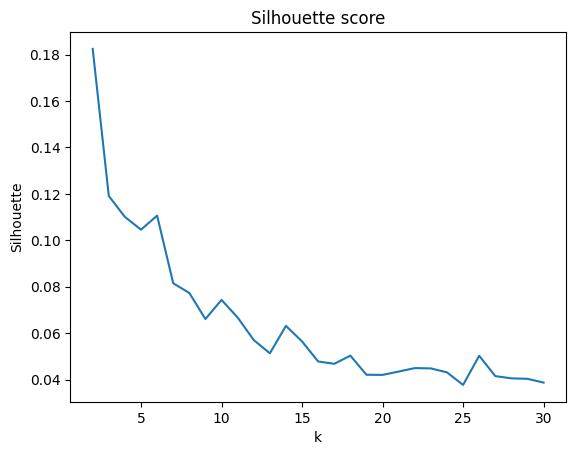

In [453]:
plt.figure()
plt.plot(list(k_range), sil_scores)
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette score")
plt.show()

In [454]:
best_k = list(k_range)[np.argmax(sil_scores)]
print("Лучшее k:", best_k)

Лучшее k: 2


In [455]:
pipe = Pipeline([
        ("prep", preprocessor),
        ("kmeans", KMeans(n_clusters=3, random_state=42, n_init=20))
    ])

In [456]:
labels = pipe.fit_predict(df)

In [457]:
counts = np.bincount(labels)

cluster_stats = pd.DataFrame({
    "cluster": np.arange(len(counts)),
    "size": counts,
    "share": counts / counts.sum()
}).sort_values("size", ascending=False)
cluster_stats

,cluster,size,share
0,0,358,0.525698
1,1,189,0.277533
2,2,134,0.196769


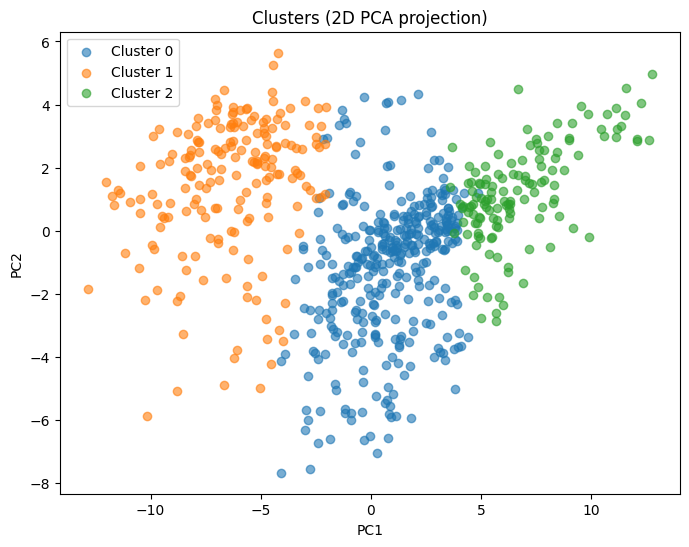

In [458]:
X_processed = pipe["prep"].transform(df)

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_processed)

plt.figure(figsize=(8,6))

for cluster in np.unique(labels):
    mask = labels == cluster
    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.legend()
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters (2D PCA projection)")
plt.show()

In [459]:
print("Объясненная дисперсия:", pca_2d.explained_variance_ratio_.sum())

Объясненная дисперсия: 0.32109916972700436


In [462]:
df_with_clusters = df_with_vuz.copy()
df_with_clusters["cluster"] = labels

In [463]:
df_with_clusters.head()

,ege_avg_budget_full_time,ege_avg_paid_full_time,ege_min_avg_full_time,olympiad_final_winners_admitted_no_exams,school_olympiad_winners_admitted_no_exams,target_admission_count_full_time,target_admission_share_full_time,masters_share_in_total_contingent,postgrad_and_residency_share_in_total_contingent,masters_admitted_from_other_orgs_share_full_time,...,pcs_internet_share,income_federal_budget_share,income_regional_local_budget_share,income_edu_share_total,nonbudget_share_in_research_income,vuz,type,size_factor,macro_reg,cluster
0,0.00,61.28,48.28,0.0,0.0,0.0,0.0,2.234306,2.234306,63.16,...,100.0,0.00,0.0,80.76,100.00,Автономная некоммерческая образовательная орга...,Частные образовательные организации,-0.856068,Central,1
1,51.69,51.48,39.26,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00,...,100.0,57.18,0.0,66.01,100.00,Автономная некоммерческая образовательная орга...,Частные образовательные организации,-1.804639,Central,1
2,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00,...,100.0,2.01,0.0,97.58,0.00,Автономная некоммерческая образовательная орга...,Частные образовательные организации,-4.774799,Central,1
3,0.00,55.70,55.70,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00,...,100.0,0.00,0.0,68.66,100.00,Автономная некоммерческая образовательная орга...,Частные образовательные организации,-5.450203,Central,1
4,0.00,0.00,0.00,0.0,0.0,0.0,0.0,4.615121,4.615121,100.00,...,100.0,82.93,0.0,9.09,12.17,Автономная некоммерческая образовательная орга...,Частные образовательные организации,1.552407,Central,2


In [472]:
df_plot = pd.DataFrame({
    "PC1": X_2d[:, 0],
    "PC2": X_2d[:, 1],
    "University": df_with_clusters["vuz"],
    "Cluster": df_with_clusters["cluster"],
    "Size": df_with_clusters["size_factor"]
})

In [473]:
fig = px.scatter(
    df_plot,
    x="PC1",
    y="PC2",
    color="Size",
    hover_name="University",
    template="plotly_dark"
)

fig.update_layout(title="PCA проекция университетов")
fig.show()

In [476]:
df_with_clusters.groupby("cluster")["size_factor"].agg(["mean", "median"])

,mean,median
cluster,,
0,0.598794,0.824903
1,-3.138102,-2.900997
2,2.826366,2.764811


## Уменьшение размерности и кластеризация

In [502]:
pipe = Pipeline([
        ("prep", preprocessor),
        ("pca", PCA(n_components=3)),
        ("kmeans", KMeans(n_clusters=3, random_state=42, n_init=10))
    ])

In [503]:
pipe.fit(df)

,steps,"[('prep', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [504]:
df_with_clusters = df.copy()

In [505]:
df_with_clusters["cluster_pca"] = pipe.named_steps["kmeans"].labels_

In [506]:
X_pca = pipe.named_steps["pca"].transform(
    pipe.named_steps["prep"].transform(df_with_clusters)
)

In [507]:
sil_score = silhouette_score(X_pca, df_with_clusters["cluster_pca"])
sil_score

0.3917790139869301

In [508]:
pipe.named_steps["pca"].n_components_

3

In [509]:
pipe.named_steps["pca"].explained_variance_ratio_.sum()

0.37256632430105097

In [510]:
df_plot = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": df_with_clusters["cluster_pca"].astype(str),
})

fig = px.scatter(
    df_plot,
    x="PC1",
    y="PC2",
    color="Cluster",
)

fig.show()

In [511]:
df_plot = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "PC3": X_pca[:, 2],
    "Cluster": df_with_clusters["cluster_pca"].astype(str)
})

fig = px.scatter_3d(
    df_plot,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Cluster",
)

fig.update_layout(title="3D PCA Clustering")
fig.show()

In [512]:
feature_names = pipe.named_steps["prep"].get_feature_names_out()

In [513]:
pca = pipe.named_steps["pca"]
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings.head()

,PC1,PC2,PC3
num__ege_avg_budget_full_time,0.149052,-0.166190,0.042354
num__ege_avg_paid_full_time,0.097685,0.015561,0.060626
num__ege_min_avg_full_time,0.083175,-0.080592,0.053920
num__olympiad_final_winners_admitted_no_exams,0.087394,0.083948,-0.154812
num__school_olympiad_winners_admitted_no_exams,0.121496,0.093930,-0.160686


Важность по первой компоненте

In [514]:
pc1_importance = (
    loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
)

pc1_importance.head(15)

num__postgrads_total                                     0.182721
num__foreign_students_total                              0.170939
num__foreign_postgrads_total                             0.163982
num__intl_coauthored_articles_count                      0.163557
num__dissertation_councils_count                         0.161288
num__target_admission_count_full_time                    0.159711
num__dorms_area                                          0.157797
num__dpo_listeners_total                                 0.156802
num__researchers_total                                   0.150153
num__ege_avg_budget_full_time                            0.149052
num__postgrad_and_residency_share_in_total_contingent    0.147541
num__journals_count                                      0.147165
num__postgrads_full_time_share                           0.144289
num__edu_funds_from_foreign_entities                     0.143311
num__small_enterprises_count                             0.134848
Name: PC1,

Важность по второй компоненте

In [515]:
pc2_importance = (
    loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
)

pc2_importance.head(15)

num__students_part_time_evening            0.240823
num__income_nonbudget_share_total          0.235673
num__faculty_phd_dsc_share                 0.225059
num__rnd_income_per_faculty_excl_budget    0.221424
num__faculty_phd_share                     0.218057
num__share_full_time                       0.204615
num__share_bachelor_in_total               0.202795
num__income_nonbudget_per_faculty          0.202433
num__nonbudget_share_in_research_income    0.197304
num__teaching_lab_area_operational         0.195050
num__income_federal_budget_share           0.178803
num__ege_avg_budget_full_time              0.166190
num__target_admission_share_full_time      0.147055
num__postgrad_per_100_students             0.146278
num__rnd_income_share_total                0.145165
Name: PC2, dtype: float64

Важность по третьей компоненте

In [516]:
pc3_importance = (
    loadings["PC3"]
    .abs()
    .sort_values(ascending=False)
)

pc3_importance.head(15)

num__students_correspondence                      0.262925
num__income_per_student                           0.236560
num__faculty_phd_dsc_per_100_students             0.231987
num__faculty_phd_share                            0.181681
num__pcs_per_student                              0.174805
num__faculty_staff_share                          0.174700
num__visiting_professors_count                    0.172046
num__foreign_faculty_share                        0.171446
num__school_olympiad_winners_admitted_no_exams    0.160686
num__faculty_phd_dsc_share                        0.158364
num__foreign_students_non_cis_share               0.157974
num__teaching_lab_area_per_student_total          0.156709
num__olympiad_final_winners_admitted_no_exams     0.154812
num__publications_rinc_per_100_faculty            0.154753
num__postgrad_from_other_orgs_share               0.151631
Name: PC3, dtype: float64

Общая важность

In [517]:
explained = pca.explained_variance_ratio_

weighted_importance = (
    loadings.abs()
    .mul(explained, axis=1)
    .sum(axis=1)
    .sort_values(ascending=False)
)

weighted_importance.head(15)

num__dorms_area                          0.051500
num__postgrads_total                     0.050734
num__foreign_postgrads_total             0.050645
num__ege_avg_budget_full_time            0.050500
num__dissertation_councils_count         0.049749
num__intl_coauthored_articles_count      0.049719
num__researchers_total                   0.049669
num__income_nonbudget_share_total        0.049136
num__share_full_time                     0.048447
num__foreign_students_total              0.048302
num__teaching_lab_area_operational       0.048158
num__income_federal_budget_share         0.047644
num__visiting_professors_count           0.047088
num__target_admission_count_full_time    0.046326
num__dpo_listeners_total                 0.046261
dtype: float64

In [519]:
cluster_means = (
    df_with_clusters.groupby("cluster_pca")
    .mean(numeric_only=True)
)

Важность через различия между кластерами

In [520]:
between_cluster_var = cluster_means.var().sort_values(ascending=False)
between_cluster_var.head(15)

postgrads_full_time_share                           1533.611477
ege_avg_budget_full_time                            1106.024894
income_federal_budget_share                          917.205142
income_nonbudget_share_total                         849.604056
share_full_time                                      463.268545
masters_admitted_from_other_orgs_share_full_time     278.668424
dpo_external_listeners_share                         242.684992
rnd_own_work_share_in_rnd_income                     162.391780
share_bachelor_in_total                              149.665739
ege_avg_all_forms                                    139.034878
ege_avg_paid_full_time                               133.831311
postgrad_from_other_orgs_share                       120.991875
faculty_staff_share                                   94.610655
nonbudget_share_in_research_income                    87.325969
ege_min_avg_full_time                                 60.134170
dtype: float64

Структура скорее градиентная, а не кластерная. Кластеры сильно различаются по структуре контингента различия не только по размеру, есть организационно-структурные отличия

In [522]:
top_features = [
    "share_full_time",
    "masters_admitted_from_other_orgs_share_full_time",
    "dpo_external_listeners_share",
    "rnd_own_work_share_in_rnd_income",
    "share_bachelor_in_total"
]

df_with_clusters.groupby("cluster_pca")[top_features].mean()

,share_full_time,masters_admitted_from_other_orgs_share_full_time,dpo_external_listeners_share,rnd_own_work_share_in_rnd_income,share_bachelor_in_total
cluster_pca,,,,,
0,76.930444,49.076593,77.947333,94.438741,60.559852
1,61.404129,49.904101,77.496208,89.784691,65.414551
2,34.396526,20.585474,50.742105,70.410789,83.755474


Кластер 0 – крупные или продвинутые исследовательские университеты с развитой магистратурой, 1 – универсальные вузы со смешанной моделью (образование + исследования, но менее «элитные», чем кластер 0), 2 – преимущественно бакалаврские, прикладные, возможно региональные вузы